Starting DP Value Iteration...
DP Converged after 180 iterations.
DP Solving Time: 0.06 seconds

--- DP Results ---
DP Optimal Value Function (Cost-to-go):
[ 9975.52929119 10395.3598634  10833.34906242 11282.54877074
 11735.65491719 12184.97974586 12622.43247962 13039.48855338
 13427.19035055 13776.08783462 14076.22727146 14317.12289478
 14487.80983175 14576.69868109 14576.69868109 14576.69868109
 14576.69868109 14576.69868109 14576.69868109 14576.69868109
 14576.69868109]
DP Optimal Policy (0=KEEP, 1=REPLACE):
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1]
DP Replacement Threshold: ~65000 km
Using device: cpu

Starting DQN Training...
Episode 50/1000	 Avg Reward: -248920.83	 Avg Loss: 702.1164	 Epsilon: 0.050
Episode 100/1000	 Avg Reward: -169161.80	 Avg Loss: 343.2976	 Epsilon: 0.050
Episode 150/1000	 Avg Reward: -132009.45	 Avg Loss: 101.8953	 Epsilon: 0.050
Episode 200/1000	 Avg Reward: -133637.12	 Avg Loss: 64.3290	 Epsilon: 0.050
Episode 250/1000	 Avg Reward: -132603.27	 Avg Loss: 6

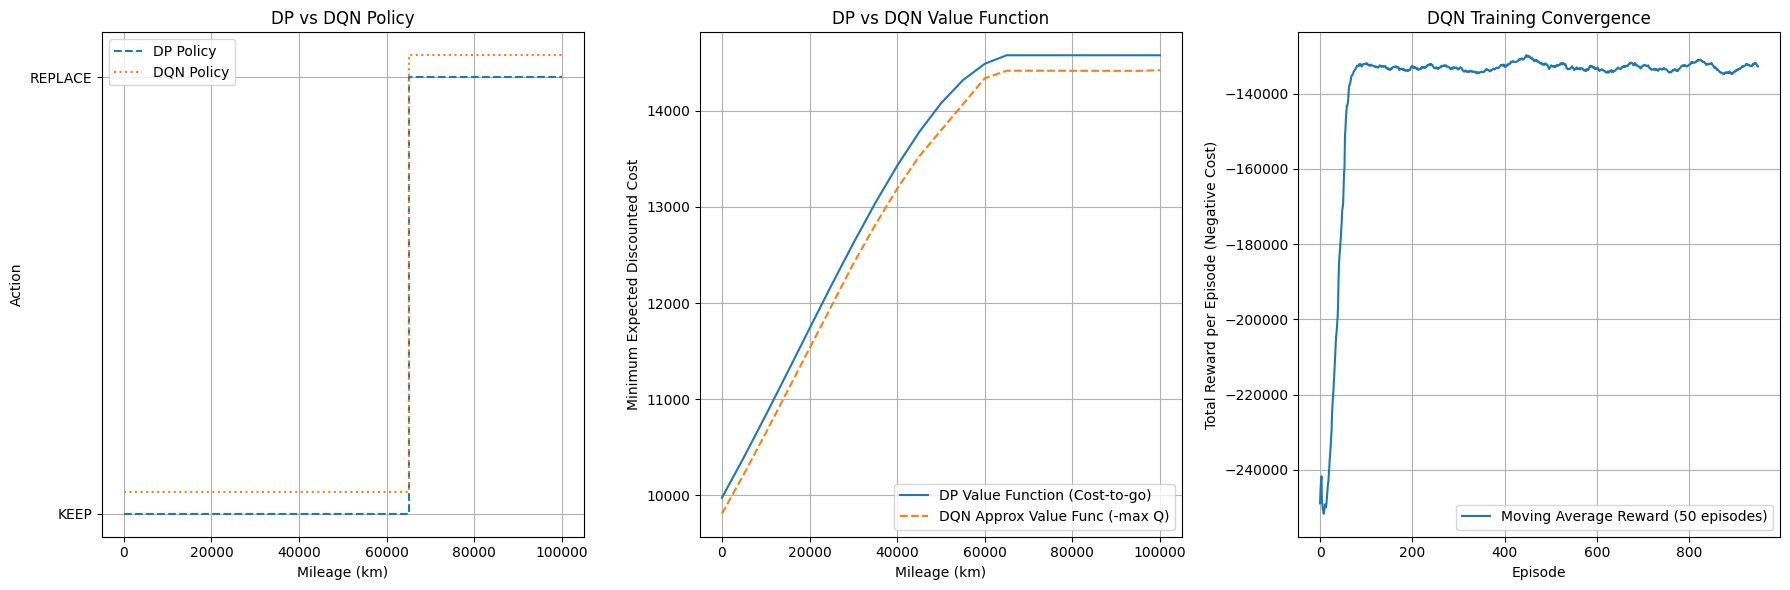

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
from collections import namedtuple, deque
import matplotlib.pyplot as plt
import time

# --- Configuration ---
MAX_MILEAGE_KM = 100000  # Max mileage considered (e.g., 100k km)
MILEAGE_STEP_KM = 5000   # Discretization step (e.g., 5k km)
N_STATES = MAX_MILEAGE_KM // MILEAGE_STEP_KM + 1 # Number of discrete mileage states
ACTION_KEEP = 0
ACTION_REPLACE = 1
N_ACTIONS = 2

REPLACEMENT_COST = 5000 # Cost to replace the engine
GAMMA = 0.95            # Discount factor

# Operating cost function (increases with mileage)
def operating_cost(mileage_km):
    # Example: Quadratic cost - scales significantly at higher mileage
    # Normalize mileage to avoid huge numbers in cost
    normalized_mileage = mileage_km / MAX_MILEAGE_KM
    # Base cost + mileage-dependent cost
    return 100 + 1500 * (normalized_mileage ** 2)

# Transition function (stochastic mileage increase)
MIN_MONTHLY_KM = 3000
MAX_MONTHLY_KM = 7000
N_TRANSITION_SAMPLES = 10 # Number of samples for DP expectation calculation

# DQN Hyperparameters
BUFFER_SIZE = 10000     # Replay buffer size
BATCH_SIZE = 64         # Minibatch size
LR = 1e-3               # Learning rate
TARGET_UPDATE = 100     # How often to update the target network (steps)
EPS_START = 0.9         # Starting epsilon for exploration
EPS_END = 0.05          # Minimum epsilon
EPS_DECAY = 500         # Epsilon decay rate (episodes)
N_EPISODES_DQN = 1000   # Number of training episodes for DQN

# --- Helper Functions ---
def state_to_index(mileage_km):
    """Converts continuous mileage to discrete state index."""
    idx = min(N_STATES - 1, int(np.round(mileage_km / MILEAGE_STEP_KM)))
    return idx

def index_to_mileage(state_index):
    """Converts discrete state index back to representative mileage."""
    return state_index * MILEAGE_STEP_KM

# --- Environment Simulation ---
class BusEnv:
    def __init__(self):
        self.state_mileage = 0 # Start with a new engine

    def reset(self):
        self.state_mileage = 0
        return state_to_index(self.state_mileage)

    def step(self, action_index):
        """
        Performs one step in the environment.
        Returns: next_state_idx, cost, done (always False for infinite horizon)
        """
        current_state_idx = state_to_index(self.state_mileage)
        current_mileage = index_to_mileage(current_state_idx) # Use representative mileage for cost calc

        cost = 0
        next_mileage = 0

        if action_index == ACTION_KEEP:
            op_cost = operating_cost(current_mileage)
            cost = op_cost
            # Stochastic mileage increase
            mileage_increase = random.uniform(MIN_MONTHLY_KM, MAX_MONTHLY_KM)
            next_mileage = self.state_mileage + mileage_increase
            # Cap mileage at max
            next_mileage = min(next_mileage, MAX_MILEAGE_KM)

        elif action_index == ACTION_REPLACE:
            op_cost_new = operating_cost(0)
            cost = REPLACEMENT_COST + op_cost_new
            next_mileage = 0 # Reset mileage

        self.state_mileage = next_mileage
        next_state_idx = state_to_index(self.state_mileage)
        done = False # Infinite horizon problem

        # DQN typically maximizes reward, so we use negative cost
        reward = -cost

        return next_state_idx, reward, done

# --- Dynamic Programming (Value Iteration) ---
class DPSolver:
    def __init__(self):
        self.V = np.zeros(N_STATES)  # Value function V(s) - represents min expected future cost
        self.policy = np.zeros(N_STATES, dtype=int) # Policy pi(s)

    def _calculate_expected_next_value(self, current_state_idx, V_old):
        """Calculate expected value after taking ACTION_KEEP from current_state_idx."""
        expected_v = 0
        current_mileage = index_to_mileage(current_state_idx)

        if current_mileage >= MAX_MILEAGE_KM: # If already maxed out, stays maxed out
             return V_old[N_STATES - 1]

        for _ in range(N_TRANSITION_SAMPLES):
            mileage_increase = random.uniform(MIN_MONTHLY_KM, MAX_MONTHLY_KM)
            next_mileage_cont = current_mileage + mileage_increase
            next_state_idx = state_to_index(next_mileage_cont)
            expected_v += V_old[next_state_idx]

        return expected_v / N_TRANSITION_SAMPLES

    def solve(self, tolerance=1e-3, max_iterations=1000):
        print("Starting DP Value Iteration...")
        start_time = time.time()
        for i in range(max_iterations):
            delta = 0
            V_old = self.V.copy()

            for s_idx in range(N_STATES):
                mileage = index_to_mileage(s_idx)

                # Cost if we KEEP
                cost_keep = operating_cost(mileage)
                expected_future_cost_keep = self._calculate_expected_next_value(s_idx, V_old)
                q_keep = cost_keep + GAMMA * expected_future_cost_keep

                # Cost if we REPLACE
                cost_replace = REPLACEMENT_COST + operating_cost(0)
                # Replacing always leads to state 0
                q_replace = cost_replace + GAMMA * V_old[0]

                # Bellman update (minimizing cost)
                v_new = min(q_keep, q_replace)
                delta = max(delta, abs(v_new - V_old[s_idx]))
                self.V[s_idx] = v_new

            if delta < tolerance:
                print(f"DP Converged after {i+1} iterations.")
                break
        else: # If loop finishes without break
             print(f"DP did not converge within {max_iterations} iterations.")

        # Extract policy
        for s_idx in range(N_STATES):
            mileage = index_to_mileage(s_idx)
            cost_keep = operating_cost(mileage)
            expected_future_cost_keep = self._calculate_expected_next_value(s_idx, self.V)
            q_keep = cost_keep + GAMMA * expected_future_cost_keep

            cost_replace = REPLACEMENT_COST + operating_cost(0)
            q_replace = cost_replace + GAMMA * self.V[0]

            self.policy[s_idx] = ACTION_REPLACE if q_replace < q_keep else ACTION_KEEP

        end_time = time.time()
        print(f"DP Solving Time: {end_time - start_time:.2f} seconds")
        return self.V, self.policy

# --- DQN Implementation ---

# Define the Q-Network structure
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super(QNetwork, self).__init__()
        # Simple MLP: Input state -> Hidden Layer -> Output Q-values for each action
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_size)

    def forward(self, state):
        # State needs to be float tensor
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# Define the Replay Buffer
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

class ReplayBuffer:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        """Sample a batch of transitions"""
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

# Define the DQN Agent
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")

        # Q-Network & Target Network
        self.policy_net = QNetwork(state_size, action_size).to(self.device)
        self.target_net = QNetwork(state_size, action_size).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval() # Target network is only for inference

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=LR)
        self.memory = ReplayBuffer(BUFFER_SIZE)
        self.steps_done = 0
        self.epsilon = EPS_START

    def _state_to_tensor(self, state_idx):
         # Convert state index to a simple feature vector (just the index itself)
         # Needs to be float and have batch dimension
         return torch.tensor([[state_idx]], dtype=torch.float32, device=self.device)

    def select_action(self, state_idx):
        """Selects action using Epsilon-Greedy strategy"""
        sample = random.random()
        # Epsilon decay
        self.epsilon = EPS_END + (EPS_START - EPS_END) * \
                       np.exp(-1. * self.steps_done / (N_EPISODES_DQN * 0.8)) # Adjust decay speed maybe
        self.steps_done += 1 # Count steps globally for decay

        if sample > self.epsilon:
            with torch.no_grad():
                # Get Q-values from policy network for the current state
                state_tensor = self._state_to_tensor(state_idx)
                q_values = self.policy_net(state_tensor)
                # Choose the action with the highest Q-value
                # print(f"State: {state_idx}, Q-values: {q_values.cpu().numpy()}, Epsilon: {self.epsilon:.3f}")
                return torch.argmax(q_values).item() # .item() gets the Python number
        else:
            # Choose a random action
            return random.randrange(self.action_size)

    def train(self):
        """Train the policy network using samples from the replay buffer."""
        if len(self.memory) < BATCH_SIZE:
            return # Not enough samples yet

        transitions = self.memory.sample(BATCH_SIZE)
        # Transpose the batch (see https://stackoverflow.com/a/19343/3343043)
        batch = Transition(*zip(*transitions))

        # Convert batch arrays to tensors
        # Filter out None next_states if we were handling terminal states
        non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), device=self.device, dtype=torch.bool)
        non_final_next_states_indices = [s for s in batch.next_state if s is not None]

        # Check if there are any non-final next states before creating the tensor
        if len(non_final_next_states_indices) > 0:
             non_final_next_states = torch.tensor(non_final_next_states_indices, dtype=torch.float32, device=self.device).unsqueeze(1)
        else:
             non_final_next_states = torch.empty((0, 1), dtype=torch.float32, device=self.device) # Create empty tensor if all are final


        state_batch = torch.tensor(batch.state, dtype=torch.float32, device=self.device).unsqueeze(1)
        action_batch = torch.tensor(batch.action, dtype=torch.int64, device=self.device).unsqueeze(1) # Needs to be Long for gather
        reward_batch = torch.tensor(batch.reward, dtype=torch.float32, device=self.device)

        # Compute Q(s_t, a) - the model computes Q(s_t), then we select the columns of actions taken
        state_action_values = self.policy_net(state_batch).gather(1, action_batch)

        # Compute V(s_{t+1}) for all next states.
        # Expected values of actions for non_final_next_states are computed based
        # on the "older" target_net; selecting their best reward with max(1)[0].
        next_state_values = torch.zeros(BATCH_SIZE, device=self.device)
        if len(non_final_next_states_indices) > 0: # Only compute if there are non-final states
            with torch.no_grad(): # No gradient needed for target net calculation
                 next_state_values[non_final_mask] = self.target_net(non_final_next_states).max(1)[0]


        # Compute the expected Q values (TD Target)
        expected_state_action_values = (next_state_values * GAMMA) + reward_batch

        # Compute Huber loss (or MSE loss)
        loss = F.smooth_l1_loss(state_action_values, expected_state_action_values.unsqueeze(1))
        # loss = F.mse_loss(state_action_values, expected_state_action_values.unsqueeze(1))


        # Optimize the model
        self.optimizer.zero_grad()
        loss.backward()
        # torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), 100) # Optional: Gradient clipping
        self.optimizer.step()

        return loss.item() # Return loss for monitoring

    def update_target_network(self):
        """Copies weights from policy_net to target_net."""
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def get_policy(self):
        """Extracts the greedy policy from the learned Q-network."""
        policy = np.zeros(N_STATES, dtype=int)
        q_values_all = np.zeros((N_STATES, N_ACTIONS))
        with torch.no_grad():
            for s_idx in range(N_STATES):
                state_tensor = self._state_to_tensor(s_idx)
                q_vals = self.policy_net(state_tensor).cpu().numpy().flatten()
                policy[s_idx] = np.argmax(q_vals)
                q_values_all[s_idx, :] = q_vals
        return policy, q_values_all

# --- Main Execution ---
if __name__ == "__main__":

    # --- 1. Solve with Dynamic Programming ---
    dp_solver = DPSolver()
    dp_V, dp_policy = dp_solver.solve(tolerance=0.1) # Lower tolerance for faster DP

    print("\n--- DP Results ---")
    print(f"DP Optimal Value Function (Cost-to-go):\n{dp_V}")
    print(f"DP Optimal Policy (0=KEEP, 1=REPLACE):\n{dp_policy}")

    # Find the threshold mileage for replacement in DP
    dp_replace_threshold_idx = np.where(dp_policy == ACTION_REPLACE)[0]
    if len(dp_replace_threshold_idx) > 0:
        dp_replace_threshold_km = index_to_mileage(dp_replace_threshold_idx[0])
        print(f"DP Replacement Threshold: ~{dp_replace_threshold_km} km")
    else:
        print("DP Policy: Never Replace")


    # --- 2. Solve with DQN ---
    env = BusEnv()
    agent = DQNAgent(state_size=1, action_size=N_ACTIONS) # State is just the index

    episode_rewards = []
    losses = []
    total_steps = 0

    print("\nStarting DQN Training...")
    start_time_dqn = time.time()

    for i_episode in range(N_EPISODES_DQN):
        state_idx = env.reset()
        episode_reward = 0
        episode_loss = []

        # Simulate for a fixed number of steps per episode, or until 'done' if applicable
        # Since it's infinite horizon, let's run for a fixed T steps
        max_steps_per_episode = 200
        for t in range(max_steps_per_episode):
            action = agent.select_action(state_idx)
            next_state_idx, reward, done = env.step(action) # reward is -cost
            episode_reward += reward # Sum of negative costs

            # Store transition in replay buffer
            # For DQN state, we pass the index directly
            agent.memory.push(state_idx, action, next_state_idx, reward)

            # Move to the next state
            state_idx = next_state_idx

            # Perform one step of optimization (on the policy network)
            loss = agent.train()
            if loss is not None:
                 episode_loss.append(loss)

            # Update the target network periodically
            if total_steps % TARGET_UPDATE == 0:
                agent.update_target_network()

            total_steps += 1
            if done: # Should not happen in this infinite horizon setup
                 break

        avg_loss = np.mean(episode_loss) if episode_loss else 0
        losses.append(avg_loss)
        episode_rewards.append(episode_reward) # Store total reward for the episode

        if (i_episode + 1) % 50 == 0:
            print(f'Episode {i_episode+1}/{N_EPISODES_DQN}\t Avg Reward: {np.mean(episode_rewards[-50:]):.2f}\t Avg Loss: {np.mean(losses[-50:]):.4f}\t Epsilon: {agent.epsilon:.3f}')

        # Simple convergence check: Check if avg reward has plateaued
        if i_episode > 100 and np.mean(episode_rewards[-50:]) > np.mean(episode_rewards[-100:-50]) * 0.98 : # Check if reward is roughly stable
             #pass # Could add early stopping, but let's run all episodes for comparison
             pass


    end_time_dqn = time.time()
    print(f"\nDQN Training finished.")
    print(f"DQN Training Time: {end_time_dqn - start_time_dqn:.2f} seconds")

    # --- 3. Compare Results ---
    dqn_policy, dqn_q_values = agent.get_policy()

    print("\n--- DQN Results ---")
    # Convert Q-values (expected rewards) back to expected costs for comparison
    # Q(s,a) = E[R_t + gamma*R_{t+1} + ...] = E[-C_t - gamma*C_{t+1} + ...]
    # So, approx Cost-to-go V(s) = -max_a Q(s,a)
    dqn_V_approx = -np.max(dqn_q_values, axis=1)

    # print(f"DQN Learned Q-Values (approx negative cost-to-go):\n{dqn_q_values}")
    print(f"DQN Learned Policy (0=KEEP, 1=REPLACE):\n{dqn_policy}")
    print(f"DQN Approx Value Function (Cost-to-go):\n{dqn_V_approx}")

    # Find the threshold mileage for replacement in DQN
    dqn_replace_threshold_idx = np.where(dqn_policy == ACTION_REPLACE)[0]
    if len(dqn_replace_threshold_idx) > 0:
        dqn_replace_threshold_km = index_to_mileage(dqn_replace_threshold_idx[0])
        print(f"DQN Replacement Threshold: ~{dqn_replace_threshold_km} km")
    else:
        print("DQN Policy: Never Replace")

    print("\n--- Comparison ---")
    policy_diff = np.sum(dp_policy != dqn_policy)
    print(f"Number of states with different policies: {policy_diff} out of {N_STATES}")
    print(f"DP Threshold: ~{dp_replace_threshold_km if 'dp_replace_threshold_km' in locals() else 'N/A'} km")
    print(f"DQN Threshold: ~{dqn_replace_threshold_km if 'dqn_replace_threshold_km' in locals() else 'N/A'} km")


    # --- 4. Plotting ---
    mileage_axis = [index_to_mileage(i) for i in range(N_STATES)]

    plt.figure(figsize=(18, 6))

    # Plot Policies
    plt.subplot(1, 3, 1)
    plt.step(mileage_axis, dp_policy, where='post', label='DP Policy', linestyle='--')
    plt.step(mileage_axis, dqn_policy + 0.05, where='post', label='DQN Policy', linestyle=':') # Offset slightly for visibility
    plt.yticks([0, 1], ['KEEP', 'REPLACE'])
    plt.xlabel('Mileage (km)')
    plt.ylabel('Action')
    plt.title('DP vs DQN Policy')
    plt.legend()
    plt.grid(True)

    # Plot Value Functions (Cost-to-go)
    plt.subplot(1, 3, 2)
    plt.plot(mileage_axis, dp_V, label='DP Value Function (Cost-to-go)')
    # Note: DQN value is approximate and scale might differ
    plt.plot(mileage_axis, dqn_V_approx, label='DQN Approx Value Func (-max Q)', linestyle='--')
    plt.xlabel('Mileage (km)')
    plt.ylabel('Minimum Expected Discounted Cost')
    plt.title('DP vs DQN Value Function')
    plt.legend()
    plt.grid(True)


    # Plot DQN Training Curve (Rewards)
    plt.subplot(1, 3, 3)
    # Calculate moving average for rewards
    rewards_moving_avg = np.convolve(episode_rewards, np.ones(50)/50, mode='valid')
    plt.plot(rewards_moving_avg, label='Moving Average Reward (50 episodes)')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward per Episode (Negative Cost)')
    plt.title('DQN Training Convergence')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
from collections import namedtuple, deque
import matplotlib.pyplot as plt
import time
import itertools
import math
import pandas as pd # For table formatting
import warnings
warnings.filterwarnings("ignore", category=UserWarning) # Suppress minor warnings

#-----------------------------------------------------
# MDP Definition (Multi-Engine Replacement Problem)
#-----------------------------------------------------

# State: s = (m_1, ..., m_N), where m_i is mileage state
# Action: a = subset of engines {1, ..., N} to replace, |a| <= C
# Transition: Deterministic: m_i' = 0 if i in a, else min(MAX_MILEAGE_STATE, m_i + 1)
# Cost: c(s,a) = alpha * sum(op_cost(m_i) for i not in a) + beta * |a|
# Reward: r = -c(s,a)

# --- Configuration ---
MAX_MILEAGE_STATE = 5   # Mileage states: 0, 1, 2, 3, 4, 5 (6 levels)
NUM_MILEAGE_LEVELS = MAX_MILEAGE_STATE + 1
REPLACEMENT_CAPACITY_PER_STEP = 3 # C parameter from the text
ALPHA_OPERATING_COST_FACTOR = 1.0 # alpha parameter
BETA_REPLACEMENT_COST_UNIT = 5.0  # beta parameter
GAMMA = 0.95            # Discount factor

# DP Configuration
DP_TOLERANCE = 1e-5
DP_MAX_ITERATIONS = 10000 # Increase max iterations
DP_TIMEOUT_SECONDS = 600 # Timeout for DP on large N

# DQN Configuration
DQN_NUM_EPISODES = 500   # Number of training episodes (adjust based on N)
DQN_MAX_STEPS_PER_EPISODE = 50 # Max steps per episode
DQN_BUFFER_SIZE = 50000
DQN_BATCH_SIZE = 64
DQN_LR = 1e-3
DQN_TARGET_UPDATE_EPISODES = 10 # Update target net every X episodes
DQN_EPS_START = 1.0
DQN_EPS_END = 0.01
DQN_EPS_DECAY_FACTOR = 0.995 # Multiplicative decay per episode
# DQN Network Architecture (as described in text footnote)
DQN_HIDDEN_LAYERS = [128, 64]

# --- Helper Functions ---

def get_num_states(N):
    """Calculates the total number of states."""
    return NUM_MILEAGE_LEVELS ** N

def state_vector_to_index(state_vector, N):
    """Converts state vector (m1, ..., mN) to a unique integer index."""
    if len(state_vector) != N:
        raise ValueError(f"State vector length {len(state_vector)} != N ({N})")
    index = 0
    place_value = 1
    for i in range(N):
        # Ensure mileage state is within bounds
        m_i = min(max(0, state_vector[i]), MAX_MILEAGE_STATE)
        index += m_i * place_value
        place_value *= NUM_MILEAGE_LEVELS
    return index

def index_to_state_vector(index, N):
    """Converts a unique integer index back to a state vector."""
    state_vector = np.zeros(N, dtype=int)
    current_index = index
    for i in range(N):
        state_vector[i] = current_index % NUM_MILEAGE_LEVELS
        current_index //= NUM_MILEAGE_LEVELS
    if current_index != 0:
        # This indicates the index was too large for N levels
        raise ValueError(f"Index {index} is out of bounds for N={N}")
    return state_vector

def generate_actions(N, capacity):
    """Generates all valid actions (subsets of engines to replace <= capacity)."""
    actions = []
    engine_indices = list(range(N))
    for k in range(capacity + 1): # Iterate from size 0 (replace none) to size C
        for subset in itertools.combinations(engine_indices, k):
            actions.append(frozenset(subset)) # Use frozenset for hashability if needed
    return actions

def get_action_index(action_subset, action_list):
    """Finds the index of a specific action subset in the pre-generated list."""
    # Simple linear search, could optimize with dict if needed
    try:
        return action_list.index(action_subset)
    except ValueError:
        raise ValueError(f"Action {action_subset} not found in action list.")

def operating_cost_engine(mileage_state):
    """Cost for operating a single engine at a given mileage state."""
    # Simple quadratic cost based on state index (0=new, 5=old)
    # Ensure non-negative state index
    m_state = max(0, mileage_state)
    # Cost increases more sharply at higher mileage states
    if m_state == 0: return 0.0 # No operating cost for new engine right after replacement? Or small base cost? User text implies cost only for m_i > 0.
    # Let's match user example: alpha * sum(1{m_i > 0}). Simplest form.
    return ALPHA_OPERATING_COST_FACTOR if m_state > 0 else 0.0
    # Alternative: return ALPHA_OPERATING_COST_FACTOR * (m_state / MAX_MILEAGE_STATE)**2 # Quadratic cost


def calculate_cost(state_vector, action_subset, N):
    """Calculates the immediate cost c(s,a)."""
    op_cost = 0
    for i in range(N):
        if i not in action_subset: # Engine not replaced
            op_cost += operating_cost_engine(state_vector[i])

    replace_cost = BETA_REPLACEMENT_COST_UNIT * len(action_subset)
    return op_cost + replace_cost

def transition(state_vector, action_subset, N):
    """Calculates the next state s' given s and a."""
    next_state_vector = np.copy(state_vector)
    for i in range(N):
        if i in action_subset:
            next_state_vector[i] = 0
        else:
            next_state_vector[i] = min(MAX_MILEAGE_STATE, state_vector[i] + 1)
    return next_state_vector

#-----------------------------------------------------
# 1. Dynamic Programming (Value Iteration)
#-----------------------------------------------------
class ValueIterationSolver:
    def __init__(self, N, gamma, tolerance, max_iterations, timeout_sec):
        self.N = N
        self.gamma = gamma
        self.tolerance = tolerance
        self.max_iterations = max_iterations
        self.timeout_sec = timeout_sec

        self.num_states = get_num_states(N)
        self.actions = generate_actions(N, REPLACEMENT_CAPACITY_PER_STEP)
        self.num_actions = len(self.actions)

        self.V = np.zeros(self.num_states) # Value function (cost-to-go)
        self.policy = np.zeros(self.num_states, dtype=int) # Stores index of best action

        print(f"DP Initialized: N={N}, States={self.num_states}, Actions={self.num_actions}")


    def solve(self):
        """Performs Value Iteration."""
        print("Starting DP Value Iteration...")
        start_time = time.time()
        iterations = 0
        converged = False

        for i in range(self.max_iterations):
            iterations = i + 1
            if time.time() - start_time > self.timeout_sec:
                print(f"DP Timeout after {time.time() - start_time:.2f} seconds and {i} iterations.")
                return None, iterations, time.time() - start_time, False # Indicate timeout

            delta = 0
            V_old = self.V.copy()

            for s_idx in range(self.num_states):
                s_vec = index_to_state_vector(s_idx, self.N)
                q_values = np.full(self.num_actions, np.inf) # Minimize cost

                for a_idx, action in enumerate(self.actions):
                    cost = calculate_cost(s_vec, action, self.N)
                    next_s_vec = transition(s_vec, action, self.N)
                    next_s_idx = state_vector_to_index(next_s_vec, self.N)
                    q_values[a_idx] = cost + self.gamma * V_old[next_s_idx]

                # Bellman Optimality Update (Minimization)
                best_value = np.min(q_values)
                delta = max(delta, abs(best_value - V_old[s_idx]))
                self.V[s_idx] = best_value

            # Print progress occasionally for large N
            if self.num_states > 10000 and (i % 10 == 0 or i == self.max_iterations -1):
                 print(f"  DP Iter {i+1}/{self.max_iterations}, Delta: {delta:.6f}, Time: {time.time() - start_time:.2f}s")


            if delta < self.tolerance:
                print(f"DP Converged after {i+1} iterations.")
                converged = True
                break
        else: # Loop finished without break (max_iterations reached)
            print(f"DP did not converge within {self.max_iterations} iterations (Delta={delta:.6f}).")

        total_time = time.time() - start_time
        print(f"DP Solving Time: {total_time:.2f} seconds")

        # Extract policy (even if not fully converged)
        print("Extracting DP Policy...")
        for s_idx in range(self.num_states):
            s_vec = index_to_state_vector(s_idx, self.N)
            q_values = np.full(self.num_actions, np.inf)
            for a_idx, action in enumerate(self.actions):
                cost = calculate_cost(s_vec, action, self.N)
                next_s_vec = transition(s_vec, action, self.N)
                next_s_idx = state_vector_to_index(next_s_vec, self.N)
                q_values[a_idx] = cost + self.gamma * self.V[next_s_idx] # Use final V
            self.policy[s_idx] = np.argmin(q_values)

        # The 'Reward' in the example table seems to be V(initial_state)
        # Since V is cost-to-go, the equivalent reward is -V
        initial_state_idx = state_vector_to_index(np.zeros(self.N, dtype=int), self.N)
        dp_reward = -self.V[initial_state_idx]

        return dp_reward, iterations, total_time, converged


#-----------------------------------------------------
# 2. Deep Reinforcement Learning (DQN)
#-----------------------------------------------------

class MultiEngineEnv:
    """Environment for the multi-engine replacement problem."""
    def __init__(self, N):
        self.N = N
        self.action_list = generate_actions(N, REPLACEMENT_CAPACITY_PER_STEP)
        self.num_actions = len(self.action_list)
        self.reset()

    def reset(self):
        self.state_vector = np.zeros(self.N, dtype=int)
        return self._get_obs()

    def step(self, action_index):
        if action_index < 0 or action_index >= self.num_actions:
            raise ValueError(f"Invalid action index: {action_index}")

        action_subset = self.action_list[action_index]
        cost = calculate_cost(self.state_vector, action_subset, self.N)
        reward = -cost

        self.state_vector = transition(self.state_vector, action_subset, self.N)

        # Simple infinite horizon, done is always False
        done = False
        return self._get_obs(), reward, done

    def _get_obs(self):
        # Normalize state for DQN input
        return self.state_vector.astype(np.float32) / MAX_MILEAGE_STATE

class QNetwork(nn.Module):
    """DQN Network Architecture."""
    def __init__(self, state_size, action_size, hidden_layers):
        super(QNetwork, self).__init__()
        layers = []
        input_dim = state_size
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            input_dim = hidden_dim
        layers.append(nn.Linear(input_dim, action_size))
        self.network = nn.Sequential(*layers)

    def forward(self, state):
        return self.network(state)

# Replay Buffer (Standard implementation)
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))
class ReplayBuffer:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)
    def push(self, *args):
        self.memory.append(Transition(*args))
    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)
    def __len__(self):
        return len(self.memory)

class DQNAgent:
    def __init__(self, N, state_size, action_size, hidden_layers, buffer_size, batch_size, gamma, lr, device):
        self.N = N
        self.state_size = state_size
        self.action_size = action_size
        self.buffer_size = buffer_size
        self.batch_size = batch_size
        self.gamma = gamma
        self.lr = lr
        self.device = device

        self.policy_net = QNetwork(state_size, action_size, hidden_layers).to(device)
        self.target_net = QNetwork(state_size, action_size, hidden_layers).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval() # Target network is only for inference

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(buffer_size)
        self.epsilon = DQN_EPS_START
        self.epsilon_decay_factor = DQN_EPS_DECAY_FACTOR
        self.epsilon_min = DQN_EPS_END

        self.total_steps = 0
        self.bellman_residuals = [] # To track convergence metric

    def select_action(self, state_vector):
        """Selects action using Epsilon-Greedy strategy."""
        self.total_steps += 1
        if random.random() < self.epsilon:
            return random.randrange(self.action_size) # Explore
        else:
            with torch.no_grad():
                state_tensor = torch.from_numpy(state_vector).unsqueeze(0).to(self.device)
                q_values = self.policy_net(state_tensor)
                return torch.argmax(q_values).item() # Exploit

    def train(self):
        """Train the policy network using samples from the replay buffer."""
        if len(self.memory) < self.batch_size:
            return None # Not enough samples yet

        transitions = self.memory.sample(self.batch_size)
        batch = Transition(*zip(*transitions))

        # Convert batch arrays to tensors
        state_batch = torch.from_numpy(np.vstack(batch.state)).to(self.device)
        action_batch = torch.tensor(batch.action, dtype=torch.int64, device=self.device).unsqueeze(1)
        reward_batch = torch.tensor(batch.reward, dtype=torch.float32, device=self.device)
        next_state_batch = torch.from_numpy(np.vstack(batch.next_state)).to(self.device)

        # Compute Q(s_t, a)
        state_action_values = self.policy_net(state_batch).gather(1, action_batch)

        # Compute V(s_{t+1}) using target network: max_{a'} Q_target(s', a')
        with torch.no_grad():
            next_state_q_values = self.target_net(next_state_batch)
            next_state_values = next_state_q_values.max(1)[0] # Max Q value for next state

        # Compute the expected Q values (TD Target): r + gamma * V(s_{t+1})
        expected_state_action_values = (next_state_values * self.gamma) + reward_batch

        # Compute Bellman Residual for this batch (before optimization)
        with torch.no_grad():
            residual = torch.abs(expected_state_action_values.unsqueeze(1) - state_action_values)
            self.bellman_residuals.append(residual.mean().item())

        # Compute Huber loss (or MSE loss)
        loss = F.smooth_l1_loss(state_action_values, expected_state_action_values.unsqueeze(1))
        # loss = F.mse_loss(state_action_values, expected_state_action_values.unsqueeze(1))

        # Optimize the model
        self.optimizer.zero_grad()
        loss.backward()
        # Optional: Gradient clipping
        # torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=1.0)
        self.optimizer.step()

        return loss.item()

    def update_target_network(self):
        """Copies weights from policy_net to target_net."""
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        """Decays epsilon."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay_factor)

    def get_initial_state_reward(self):
        """Estimate V(initial_state) = max_a Q(initial_state, a)."""
        initial_state_vec = np.zeros(self.N, dtype=np.float32) / MAX_MILEAGE_STATE
        with torch.no_grad():
            state_tensor = torch.from_numpy(initial_state_vec).unsqueeze(0).to(self.device)
            q_values = self.policy_net(state_tensor)
            # Return the max Q-value (which represents negative cost-to-go)
            return q_values.max().item()

    def get_avg_bellman_residual(self, last_n=100):
        """Calculates the average Bellman residual over recent steps."""
        if not self.bellman_residuals:
            return 0.0
        return np.mean(self.bellman_residuals[-last_n:])

#-----------------------------------------------------
# Main Comparison Loop
#-----------------------------------------------------
if __name__ == "__main__":
    results = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # N_values_to_test = list(range(1, 9)) # Test N from 1 to 8
    N_values_to_test = list(range(1, 7)) # Test N from 1 to 6 for reasonable runtime

    for N in N_values_to_test:
        print(f"\n===== Running for N = {N} =====")
        num_states = get_num_states(N)
        actions = generate_actions(N, REPLACEMENT_CAPACITY_PER_STEP)
        num_actions = len(actions)

        # --- Dynamic Programming ---
        dp_reward = np.nan
        dp_time = np.nan
        dp_iterations = np.nan
        dp_converged = False
        dp_timed_out = False

        if num_states * num_actions < 1e8: # Heuristic limit for DP feasibility
            try:
                dp_solver = ValueIterationSolver(N, GAMMA, DP_TOLERANCE, DP_MAX_ITERATIONS, DP_TIMEOUT_SECONDS)
                dp_reward, dp_iterations, dp_time, dp_converged = dp_solver.solve()
                if dp_reward is None: # Check if timeout occurred
                    dp_timed_out = True
                    dp_reward = np.nan # Set reward to NaN on timeout
                    print("DP timed out, result not available.")
            except MemoryError:
                print(f"DP failed for N={N} due to MemoryError.")
                dp_time = np.inf # Indicate memory failure
            except Exception as e:
                print(f"DP failed for N={N} with error: {e}")
                dp_time = np.nan # Indicate other failure
        else:
            print(f"Skipping DP for N={N}: State-Action space ({num_states}x{num_actions}) likely too large.")
            dp_time = np.inf # Indicate skipped due to size

        # --- DQN ---
        print("\n--- Starting DQN Training ---")
        env = MultiEngineEnv(N)
        state_size = N # Input is the state vector
        action_size = env.num_actions
        agent = DQNAgent(N, state_size, action_size, DQN_HIDDEN_LAYERS,
                         DQN_BUFFER_SIZE, DQN_BATCH_SIZE, GAMMA, DQN_LR, device)

        start_time_dqn = time.time()
        episode_total_rewards = []

        # Adjust number of episodes based on N? Maybe increase slightly?
        current_dqn_episodes = DQN_NUM_EPISODES #+ N * 50 # Example adjustment

        for i_episode in range(1, current_dqn_episodes + 1):
            state = env.reset()
            episode_reward = 0
            for step in range(DQN_MAX_STEPS_PER_EPISODE):
                action = agent.select_action(state)
                next_state, reward, done = env.step(action)
                agent.memory.push(state, action, next_state, reward)
                state = next_state
                episode_reward += reward # Accumulate actual rewards

                loss = agent.train() # Train after each step

                if done: break # Should not happen in this setup

            episode_total_rewards.append(episode_reward)
            agent.decay_epsilon() # Decay epsilon after each episode

            if i_episode % DQN_TARGET_UPDATE_EPISODES == 0:
                agent.update_target_network()

            if i_episode % 50 == 0 or i_episode == current_dqn_episodes:
                 avg_reward = np.mean(episode_total_rewards[-50:]) if episode_total_rewards else 0
                 avg_res = agent.get_avg_bellman_residual(last_n=DQN_BATCH_SIZE * 10) # Avg over last few batches
                 print(f'  DQN Episode {i_episode}/{current_dqn_episodes}\tAvg Reward: {avg_reward:.2f}\tAvg Bellman Res: {avg_res:.4f}\tEpsilon: {agent.epsilon:.3f}')

        dqn_time = time.time() - start_time_dqn
        dqn_reward = agent.get_initial_state_reward() # Use estimated V(0) as reward metric
        dqn_avg_bellman_res = agent.get_avg_bellman_residual(last_n=DQN_BATCH_SIZE * 50) # Final avg residual

        print(f"DQN Training Time: {dqn_time:.2f} seconds")
        print(f"DQN Final Reward (Estimated V(0)): {dqn_reward:.2f}")
        print(f"DQN Final Avg Bellman Residual: {dqn_avg_bellman_res:.4f}")

        # Store results
        results.append({
            'N': N,
            '#States': num_states,
            'DP Time (s)': f"{dp_time:.2f}" if not np.isnan(dp_time) and not np.isinf(dp_time) else ('Timeout' if dp_timed_out else ('OOM/Skip' if np.isinf(dp_time) else '--')),
            'DP Reward': f"{dp_reward:.2f}" if not np.isnan(dp_reward) else '--',
            'DQN Time (s)': f"{dqn_time:.2f}",
            'DQN Reward': f"{dqn_reward:.2f}",
            'DQN Bell Res': f"{dqn_avg_bellman_res:.4f}"
        })

    # --- Display Results Table ---
    print("\n===== Comparison Results =====")
    df = pd.DataFrame(results)
    print(df.to_string(index=False))

    # Example Plot (DQN Reward Convergence for the last N run)
    if episode_total_rewards:
         plt.figure(figsize=(8, 5))
         # Plot moving average of episode rewards
         moving_avg = np.convolve(episode_total_rewards, np.ones(20)/20, mode='valid')
         plt.plot(moving_avg)
         plt.title(f'DQN Episode Reward Convergence (N={N}, Moving Avg)')
         plt.xlabel('Episode (smoothed)')
         plt.ylabel('Avg Total Reward per Episode')
         plt.grid(True)
         plt.tight_layout()
         plt.show()

Using device: cpu

===== Running for N = 1 =====
DP Initialized: N=1, States=6, Actions=2
Starting DP Value Iteration...
DP Converged after 226 iterations.
DP Solving Time: 0.01 seconds
Extracting DP Policy...

--- Starting DQN Training ---
  DQN Episode 50/500	Avg Reward: -129.88	Avg Bellman Res: 0.0196	Epsilon: 0.778
  DQN Episode 100/500	Avg Reward: -104.84	Avg Bellman Res: 0.0131	Epsilon: 0.606
  DQN Episode 150/500	Avg Reward: -93.30	Avg Bellman Res: 0.0118	Epsilon: 0.471
  DQN Episode 200/500	Avg Reward: -82.08	Avg Bellman Res: 0.0088	Epsilon: 0.367
  DQN Episode 250/500	Avg Reward: -74.76	Avg Bellman Res: 0.0070	Epsilon: 0.286
  DQN Episode 300/500	Avg Reward: -68.60	Avg Bellman Res: 0.0059	Epsilon: 0.222
  DQN Episode 350/500	Avg Reward: -64.36	Avg Bellman Res: 0.0041	Epsilon: 0.173
  DQN Episode 400/500	Avg Reward: -59.88	Avg Bellman Res: 0.0037	Epsilon: 0.135
  DQN Episode 450/500	Avg Reward: -59.24	Avg Bellman Res: 0.0039	Epsilon: 0.105
  DQN Episode 500/500	Avg Reward: -56.

KeyboardInterrupt: 